# Week 8 and 9 - Condition-Aware Embedded BMS Deployment

This notebook:
1. Builds a 3-dimensional condition matrix (Chemistry × Climate × Terrain)
2. Profiles every model for memory size + inference latency
3. Computes RMSE + R² per model per condition
4. Selects the best embedded-ready model per condition (penalising >2 MB models)
5. Saves `bms_matrix_full.csv` for the Streamlit app

In [14]:
#  Cell 0 : Auto-install dependencies
import subprocess, sys
for pkg in ['xgboost']:
    try:
        __import__(pkg)
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '--quiet'])
print('✅ Dependencies OK')

✅ Dependencies OK


In [15]:
# Cell 1 : Imports 
import os, time, warnings
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')
print('✅ Imports OK')

✅ Imports OK


In [16]:
# Cell 2 : Load dataset 
DATASET_PATH = 'Phase3_Deployment/features_cycle_with_core_fixed.parquet'
# if not os.path.exists(DATASET_PATH):
    

print(f'📂 Loading: {DATASET_PATH}')
df = pd.read_parquet(DATASET_PATH)
df = df.ffill().bfill().fillna(0)

print(f'   Rows    : {len(df):,}')
print(f'   Cols    : {len(df.columns)}')
print(f'   Datasets: {df["dataset"].unique() if "dataset" in df.columns else "N/A"}')

📂 Loading: Phase3_Deployment/features_cycle_with_core_fixed.parquet
   Rows    : 905
   Cols    : 48
   Datasets: ['CALB']


In [17]:
df.head()

,n_samples,duration_s,v_mean,v_std,v_min,v_max,v_p25,v_p50,v_p75,i_mean,...,current_max,temp_std,cycle_duration,charge_throughput,rc_estimate,energy_roll5,energy_norm,power_temp_xcorr_lag,core_peak_sim,core_mean_sim
0,1254.0,1253.0,4.203433,0.252992,2.1989,4.3498,4.293100,4.2934,4.293400,3.849620,...,0.0,0.0,0.0,0.0,0.0,20602.689211,2.949082,0.0,120.000000,31.840761
1,288.0,287.0,3.913968,0.403421,2.1995,4.3498,3.551300,3.9293,4.334325,16.309492,...,0.0,0.0,0.0,0.0,0.0,20323.871069,2.857144,0.0,110.353767,32.797327
2,294.0,293.0,3.928304,0.401114,2.1995,4.3498,3.571150,3.9446,4.349500,17.059141,...,0.0,0.0,0.0,0.0,0.0,20695.963402,3.087156,0.0,115.112422,35.256053
3,298.0,297.0,3.929014,0.409838,2.1995,4.3501,3.575225,3.9488,4.349800,17.276408,...,0.0,0.0,0.0,0.0,0.0,21028.267702,3.183612,0.0,116.696355,36.037185
4,299.0,298.0,3.930865,0.410678,2.1999,4.3501,3.579150,3.9512,4.350100,17.347262,...,0.0,0.0,0.0,0.0,0.0,21262.011790,3.211938,0.0,117.080175,36.319280


In [18]:
# ── Cell 3 : Build 3-D Condition Clusters ────────────────────────────────────

# DIMENSION 1 — Chemistry 
chemistry_map = {
    'CALB'    : 'NMC',
    'CALCE'   : 'NMC/LFP',
    'Stanford': 'NMC',
    'NASA'    : 'NMC',
}
df['Chemistry'] = df['dataset'].map(chemistry_map).fillna('Unknown') \
                  if 'dataset' in df.columns else 'NMC'

# DIMENSION 2 — Climate 
t33 = df['temp_mean'].quantile(0.33)
t66 = df['temp_mean'].quantile(0.66)

def classify_climate(t):
    if t < t33:   return 'Cold'
    elif t < t66: return 'Optimal'
    else:         return 'Hot'

# DIMENSION 3 — Terrain 
med_vstd = df['v_std'].median()

def classify_terrain(v):
    return 'City/Hilly' if v > med_vstd else 'Highway'

df['Climate']           = df['temp_mean'].apply(classify_climate)
df['Terrain']           = df['v_std'].apply(classify_terrain)
df['Condition_Cluster'] = df['Chemistry'] + ' | ' + df['Climate'] + ' & ' + df['Terrain']

# Drop tiny conditions (<100 rows) 
counts           = df['Condition_Cluster'].value_counts()
valid_conditions = counts[counts >= 100].index
df               = df[df['Condition_Cluster'].isin(valid_conditions)].copy()

print('🎉 Final Condition Distribution (rows ≥ 100):')
print(df['Condition_Cluster'].value_counts().to_string())
print(f'\nTotal usable conditions: {df["Condition_Cluster"].nunique()}')

🎉 Final Condition Distribution (rows ≥ 100):
Condition_Cluster
NMC | Hot & Highway           206
NMC | Cold & City/Hilly       202
NMC | Optimal & Highway       150
NMC | Optimal & City/Hilly    148
NMC | Hot & City/Hilly        102

Total usable conditions: 5


In [19]:
# Cell 4 : Resolve target column 
possible_targets = ['core_mean_sim', 'core_temperature', 'core_temp', 'core']
target_col = next((c for c in possible_targets if c in df.columns), None)
assert target_col, f'❌ No target column found! Available: {df.columns.tolist()}'
print(f'🎯 Target column: {target_col}')

🎯 Target column: core_mean_sim


In [20]:
df[target_col].describe()

count    808.000000
mean      38.426224
std        0.889454
min       31.840761
25%       37.957591
50%       38.401341
75%       38.895914
max       41.063442
Name: core_mean_sim, dtype: float64

In [21]:
len(df[df[target_col] > 20])

808

In [22]:
# Cell 5 : Model registry + sanity check
MODEL_FILES = {
    'XGBoost'                 : 'tuned_xgb_core.joblib',
    'MLP Neural Net'          : 'tuned_mlp_core.joblib',
    'Random Forest'           : 'tuned_rf_core.joblib',
    'Decision Tree'           : 'dt_core.pkl',
    'Linear Regression'       : 'lr_core.pkl',
    'Support Vector Regressor': 'svr_core.pkl',
    'K-Nearest Neighbors'     : 'knn_core.pkl',
}

SEARCH_DIRS = ['', 'Phase3_Deployment/', 'models_week5_7/']

def find_model(filename):
    for d in SEARCH_DIRS:
        p = d + filename
        if os.path.exists(p):
            return p
    return None

# Metadata columns — never used as features
META_COLS = {
    target_col, 'Condition_Cluster', 'Climate', 'Terrain', 'Chemistry',
    'dataset', 'cell_id', 'chemistry', 'cycle', 'core_mean_sim',
    'SOH_proxy', 'soh', 'core_temp_est_scalar'
}

print('🔎 Locating model files...')
for name, fn in MODEL_FILES.items():
    p = find_model(fn)
    print(f'  {"✅" if p else "❌"} {name:30s} → {p or "NOT FOUND"}')

# Sanity check: auto-detect broken/version-mismatched models
SKIP_MODELS = set()
target_std  = df[target_col].std()

print('\n🔍 Sanity-checking model prediction outputs...')
for model_name, filename in MODEL_FILES.items():
    path = find_model(filename)
    if not path:
        SKIP_MODELS.add(model_name)
        continue
    try:
        m = joblib.load(path)
        feats_check = list(m.feature_names_in_) if hasattr(m, 'feature_names_in_') \
                      else [c for c in df.columns if c not in META_COLS]
        feats_check = [f for f in feats_check if f in df.columns]
        test_pred   = m.predict(df[feats_check].iloc[:100])

        pred_std = np.std(test_pred)
        if pred_std > target_std * 10 or np.any(np.isnan(test_pred)):
            print(f'   {model_name:30s} predictions look broken '
                  f'(pred_std={pred_std:.2f} vs target_std={target_std:.4f}) — SKIPPING')
            SKIP_MODELS.add(model_name)
        else:
            print(f'  {model_name:30s} OK  (pred_std={pred_std:.4f})')
    except Exception as e:
        print(f'  {model_name}: {e}')
        SKIP_MODELS.add(model_name)

print(f'\n Skipping {len(SKIP_MODELS)} model(s): {SKIP_MODELS if SKIP_MODELS else "none"}')

🔎 Locating model files...
  ✅ XGBoost                        → Phase3_Deployment/tuned_xgb_core.joblib
  ✅ MLP Neural Net                 → Phase3_Deployment/tuned_mlp_core.joblib
  ✅ Random Forest                  → Phase3_Deployment/tuned_rf_core.joblib
  ✅ Decision Tree                  → Phase3_Deployment/dt_core.pkl
  ✅ Linear Regression              → Phase3_Deployment/lr_core.pkl
  ✅ Support Vector Regressor       → Phase3_Deployment/svr_core.pkl
  ✅ K-Nearest Neighbors            → Phase3_Deployment/knn_core.pkl

🔍 Sanity-checking model prediction outputs...
  ✅ XGBoost                        OK  (pred_std=0.0000)
  ⚠️  MLP Neural Net                 predictions look broken (pred_std=182.93 vs target_std=0.8895) — SKIPPING
  ✅ Random Forest                  OK  (pred_std=0.2380)
  ✅ Decision Tree                  OK  (pred_std=1.3075)
  ✅ Linear Regression              OK  (pred_std=1.3569)
  ✅ Support Vector Regressor       OK  (pred_std=1.2378)
  ✅ K-Nearest Neighbors        

In [23]:
# Cell 6 : Hardware profiling + raw per-condition metrics 
# Score is computed LATER in Cell 6b after normalization.

all_results    = []   # one row per (model × condition)
hw_profiles    = []   # one row per model
all_preds_dict = {}   # model_name → full predictions array

print(' Profiling models...\n')

for model_name, filename in MODEL_FILES.items():

    if model_name in SKIP_MODELS:
        print(f'  {model_name:30s} skipped (failed sanity check)')
        continue

    path = find_model(filename)
    if not path:
        print(f'  {model_name:30s} file not found')
        continue

    try:
        model = joblib.load(path)

        # Feature resolution
        if hasattr(model, 'feature_names_in_'):
            feats = [f for f in model.feature_names_in_ if f in df.columns]
        else:
            feats = [c for c in df.columns if c not in META_COLS]

        sample_X = df[feats].iloc[[0]]

        # Size
        size_mb = os.path.getsize(path) / (1024 * 1024)

        # Latency — 100-run average
        t0 = time.perf_counter()
        for _ in range(100):
            model.predict(sample_X)
        latency_ms = ((time.perf_counter() - t0) / 100) * 1000

        hw_profiles.append({
            'Model'      : model_name,
            'Size_MB'    : round(size_mb,    4),
            'Latency_ms' : round(latency_ms, 4),
            'Memory_OK'  : size_mb <= 2.0,
        })
        print(f' {model_name:30s} | {size_mb:7.2f} MB | {latency_ms:.2f} ms')

        # Full-dataset predictions (for app comparison plots)
        all_preds_dict[model_name] = model.predict(df[feats])

        # Per-condition raw metrics
        for cond, grp in df.groupby('Condition_Cluster'):
            X_grp = grp[feats]
            y_grp = grp[target_col]
            preds = model.predict(X_grp)

            rmse = np.sqrt(mean_squared_error(y_grp, preds))
            r2   = r2_score(y_grp, preds)
            mae  = np.mean(np.abs(y_grp - preds))

            parts     = cond.split(' | ')
            chemistry = parts[0] if len(parts) == 2 else 'Unknown'
            ct_parts  = parts[-1].split(' & ') if ' & ' in parts[-1] else ['', '']
            climate   = ct_parts[0]
            terrain   = ct_parts[1] if len(ct_parts) > 1 else ''

            all_results.append({
                'Condition'  : cond,
                'Chemistry'  : chemistry,
                'Climate'    : climate,
                'Terrain'    : terrain,
                'Model'      : model_name,
                'RMSE'       : round(rmse,       6),
                'R2'         : round(r2,         6),
                'MAE'        : round(mae,        6),
                'Size_MB'    : round(size_mb,    4),
                'Latency_ms' : round(latency_ms, 4),
                'Memory_OK'  : size_mb <= 2.0,
                # 'Score' added by Cell 6b
            })

    except Exception as e:
        print(f' {model_name}: {e}')

print(f'\n Raw results collected: {len(all_results)} rows across '
      f'{len(set(r["Model"] for r in all_results))} models')

⚙️  Profiling models...

✅ XGBoost                        |    0.66 MB | 1.89 ms


⏭️  MLP Neural Net                 skipped (failed sanity check)
✅ Random Forest                  |  221.02 MB | 40.76 ms
✅ Decision Tree                  |    0.03 MB | 0.79 ms
✅ Linear Regression              |    0.00 MB | 0.82 ms
✅ Support Vector Regressor       |    0.03 MB | 1.17 ms
✅ K-Nearest Neighbors            |    0.13 MB | 1.02 ms

📊 Raw results collected: 30 rows across 6 models


In [24]:
# Cell 6b : Normalized scoring 
# Min-max normalize RMSE, Latency, Size WITHIN each condition.
# This ensures the formula genuinely balances accuracy vs hardware
# without DT's near-zero RMSE making all other terms irrelevant.
# Score = 0.6×RMSE_norm + 0.2×Latency_norm + 0.2×Size_norm + penalty
# penalty = 1.0 if Size_MB > 2MB else 0.0

def minmax(series):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series([0.0] * len(series), index=series.index)
    return (series - mn) / (mx - mn)

raw_df      = pd.DataFrame(all_results)
scored_rows = []

for cond, grp in raw_df.groupby('Condition'):
    grp = grp.copy()
    grp['RMSE_norm']    = minmax(grp['RMSE'])
    grp['Latency_norm'] = minmax(grp['Latency_ms'])
    grp['Size_norm']    = minmax(grp['Size_MB'])
    grp['Penalty']      = grp['Size_MB'].apply(lambda s: 1.0 if s > 2.0 else 0.0)
    grp['Score']        = (
        0.60 * grp['RMSE_norm'] +
        0.20 * grp['Latency_norm'] +
        0.20 * grp['Size_norm'] +
        grp['Penalty']
    ).round(6)
    scored_rows.append(grp)

results_df = pd.concat(scored_rows).reset_index(drop=True)

print(' Mean Score & RMSE per model (across all conditions):')
summary = results_df.groupby('Model')[['RMSE', 'Score', 'Size_MB', 'Latency_ms']]\
                    .mean().sort_values('Score')
print(summary.to_string())
print(f'\n Score column added. Total rows: {len(results_df)}')

🎯 Mean Score & RMSE per model (across all conditions):
                               RMSE     Score   Size_MB  Latency_ms
Model                                                              
Linear Regression          0.081417  0.000148    0.0031      0.8223
Support Vector Regressor   0.324161  0.006394    0.0285      1.1741
K-Nearest Neighbors        0.459558  0.008191    0.1306      1.0168
Decision Tree              0.563231  0.008885    0.0337      0.7927
XGBoost                   32.686531  0.606102    0.6615      1.8931
Random Forest             11.020982  1.601303  221.0168     40.7629

✅ Score column added. Total rows: 30


In [25]:
# Cell 7 : Save all output files 
assert 'Score' in results_df.columns, "Run Cell 6b first!"

os.makedirs('Phase3_Deployment', exist_ok=True)

# 1. Full matrix
results_df.to_csv('Phase3_Deployment/bms_matrix_full.csv', index=False)
print(' Saved: bms_matrix_full.csv')

# 2. TOP 3 models per condition (ranked by Score)
top3_df = (
    results_df
    .sort_values('Score')
    .groupby('Condition')
    .head(3)
    .reset_index(drop=True)
)
# Add rank column: 1=Best, 2=Runner-up, 3=Third
top3_df['Rank'] = top3_df.groupby('Condition')['Score'].rank(method='first').astype(int)
top3_df.to_csv('Phase3_Deployment/bms_matrix_top3.csv', index=False)
print(' Saved: bms_matrix_top3.csv')

# 3. Best matrix (rank 1 only) — kept for backward compatibility
best_df = top3_df[top3_df['Rank'] == 1].reset_index(drop=True)
best_df.to_csv('Phase3_Deployment/bms_matrix.csv', index=False)
print(' Saved: bms_matrix.csv')

# 4. Predictions sample
sample_idx = df.sample(min(3000, len(df)), random_state=42).index
pred_df = pd.DataFrame({
    'Actual'    : df.loc[sample_idx, target_col].values,
    'Condition' : df.loc[sample_idx, 'Condition_Cluster'].values,
})
for mname, preds in all_preds_dict.items():
    s = pd.Series(preds, index=df.index)
    pred_df[mname] = s.loc[sample_idx].values
pred_df.to_csv('Phase3_Deployment/bms_predictions_sample.csv', index=False)
print(' Saved: bms_predictions_sample.csv')

# 5. Display top 3 nicely
print('\n🏆 Top 3 Models Per Condition:\n')
for cond, grp in top3_df.groupby('Condition'):
    print(f'  📍 {cond}')
    for _, row in grp.iterrows():
        medal = {1:'', 2:'', 3:''}[row['Rank']]
        mem   =  if row['Memory_OK'] else '❌'
        print(f'     {medal} #{row["Rank"]} {row["Model"]:30s} '
              f'RMSE={row["RMSE"]:.5f}  R²={row["R2"]:.5f}  '
              f'Size={row["Size_MB"]:.2f}MB {mem}  '
              f'Latency={row["Latency_ms"]:.2f}ms  Score={row["Score"]:.4f}')
    print()

💾 Saved: bms_matrix_full.csv
💾 Saved: bms_matrix_top3.csv
💾 Saved: bms_matrix.csv
💾 Saved: bms_predictions_sample.csv

🏆 Top 3 Models Per Condition:

  📍 NMC | Cold & City/Hilly
     🥇 #1 Linear Regression              RMSE=0.07288  R²=0.99002  Size=0.00MB ✅  Latency=0.82ms  Score=0.0001
     🥈 #2 Support Vector Regressor       RMSE=0.33279  R²=0.79198  Size=0.03MB ✅  Latency=1.17ms  Score=0.0067
     🥉 #3 K-Nearest Neighbors            RMSE=0.50534  R²=0.52035  Size=0.13MB ✅  Latency=1.02ms  Score=0.0093

  📍 NMC | Hot & City/Hilly
     🥇 #1 Linear Regression              RMSE=0.10227  R²=0.98272  Size=0.00MB ✅  Latency=0.82ms  Score=0.0001
     🥈 #2 Support Vector Regressor       RMSE=0.53745  R²=0.52277  Size=0.03MB ✅  Latency=1.17ms  Score=0.0099
     🥉 #3 K-Nearest Neighbors            RMSE=0.68522  R²=0.22426  Size=0.13MB ✅  Latency=1.02ms  Score=0.0119

  📍 NMC | Hot & Highway
     🥇 #1 Decision Tree                  RMSE=0.10810  R²=0.99007  Size=0.03MB ✅  Latency=0.79ms  Score

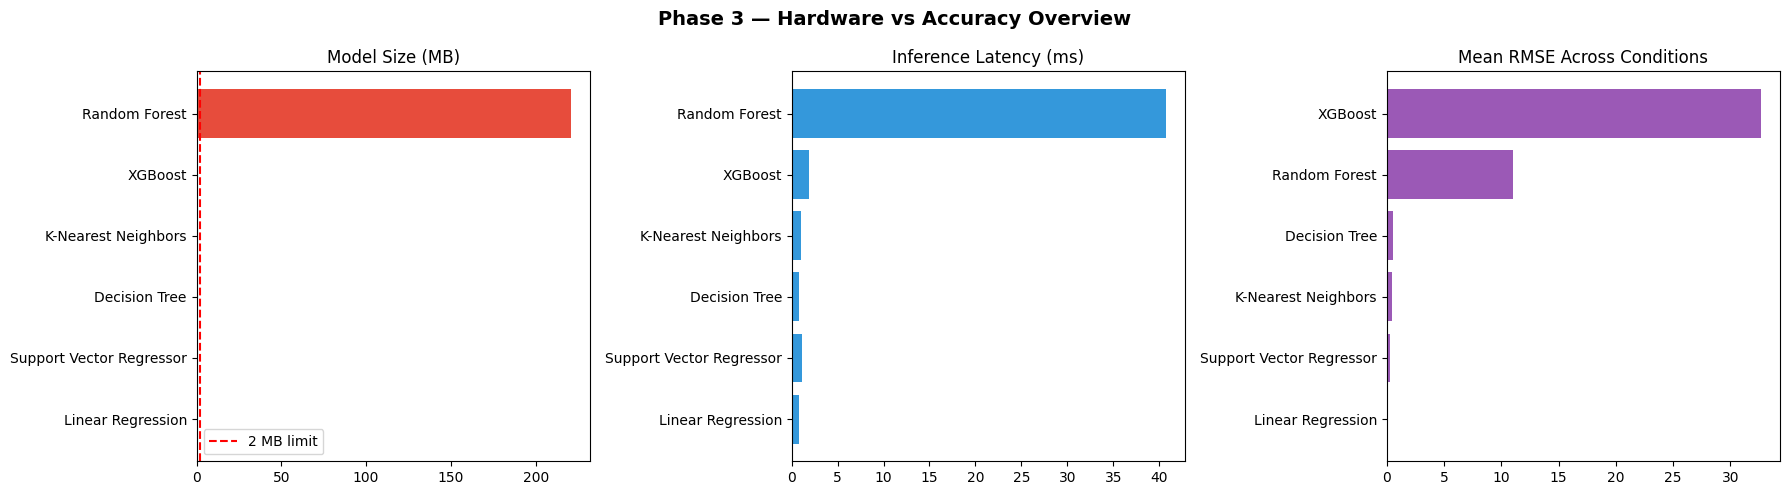

💾 Saved: overview_plots.png


In [26]:
# Cell 8 : Overview plots 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Phase 3 — Hardware vs Accuracy Overview', fontsize=14, fontweight='bold')

hw = pd.DataFrame(hw_profiles).sort_values('Size_MB')

# Plot 1 — Model Size
colors = ['#2ECC71' if s <= 2 else '#E74C3C' for s in hw['Size_MB']]
axes[0].barh(hw['Model'], hw['Size_MB'], color=colors)
axes[0].axvline(2, color='red', linestyle='--', label='2 MB limit')
axes[0].set_title('Model Size (MB)')
axes[0].legend()

# Plot 2 — Latency
axes[1].barh(hw['Model'], hw['Latency_ms'], color='#3498DB')
axes[1].set_title('Inference Latency (ms)')

# Plot 3 — Mean RMSE across conditions
mean_rmse = results_df.groupby('Model')['RMSE'].mean().sort_values()
axes[2].barh(mean_rmse.index, mean_rmse.values, color='#9B59B6')
axes[2].set_title('Mean RMSE Across Conditions')

plt.tight_layout()
plt.savefig('Phase3_Deployment/overview_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: overview_plots.png')